In [12]:
import librosa
array, sampling_rate = librosa.load(librosa.ex("trumpet"))
f"Sample Rate: {sampling_rate} | Array len: {len(array)} | Time: {len(array)/sampling_rate:.3f}sec"

'Sample Rate: 22050 | Array len: 117601 | Time: 5.333sec'

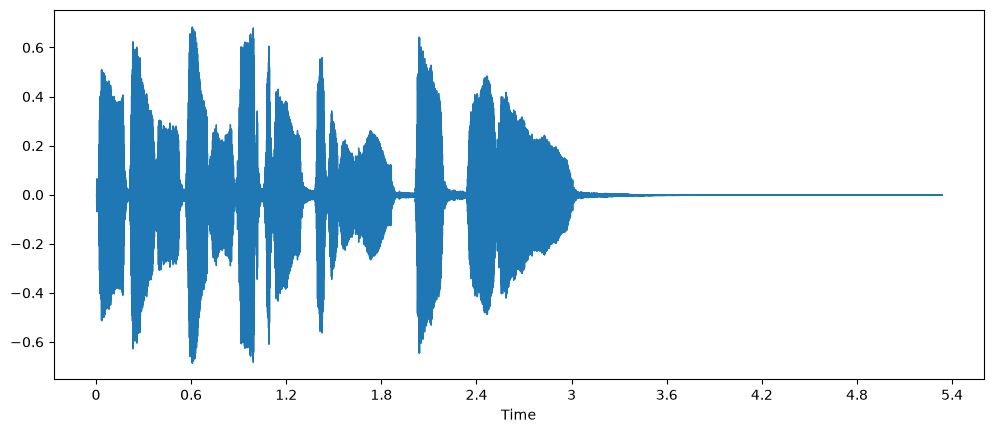

In [13]:
import matplotlib.pyplot as plt

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)
plt.show()

**Frequency spectrum**
---
The frequency spectrum of an audio signal contains the exact same information as its waveform — they are simply two different ways of looking at the same data (here, the first 4096 samples from the trumpet sound). Where the waveform plots the amplitude of the audio signal over time, the spectrum visualizes the amplitudes of the individual frequencies at a fixed point in time.

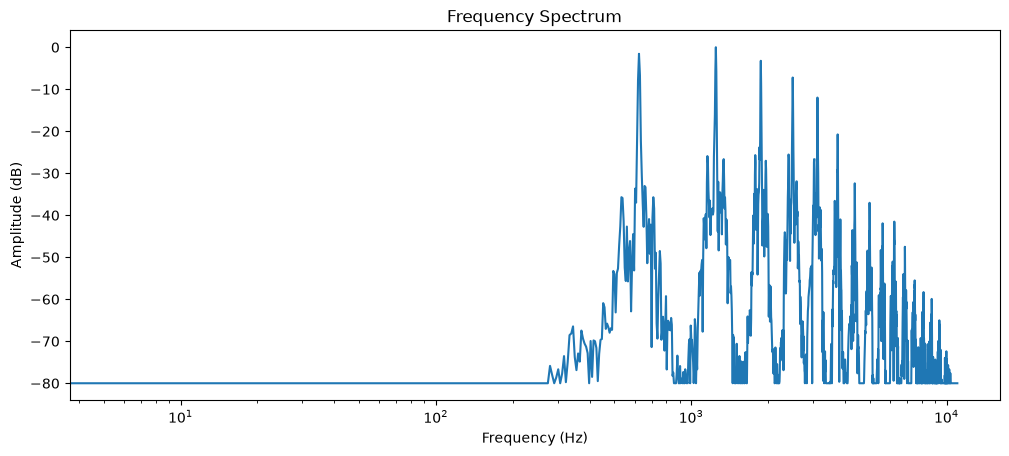

In [24]:
import numpy as np

dft_input = array[:4096]

# calculate the DFT
window = np.hanning(len(dft_input))
windowed_input = dft_input * window
dft = np.fft.rfft(windowed_input)

# get the amplitude spectrum in decibels
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

# get the frequency bins
frequency = librosa.fft_frequencies(sr=sampling_rate, n_fft=len(dft_input))

plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xscale("log")
plt.title("Frequency Spectrum")
plt.show()

**Spectogram**
---
What if we want to see how the frequencies in an audio signal change? The trumpet plays several notes and they all have different frequencies. The problem is that the spectrum only shows a frozen snapshot of the frequencies at a given instant. The solution is to take multiple DFTs, each covering only a small slice of time, and stack the resulting spectra together into a spectrogram.

The spectrogram is one of the most informative audio tools available to you. For example, when working with a music recording, you can see the various instruments and vocal tracks and how they contribute to the overall sound. **In speech, you can identify different vowel sounds as each vowel is characterized by particular frequencies.**

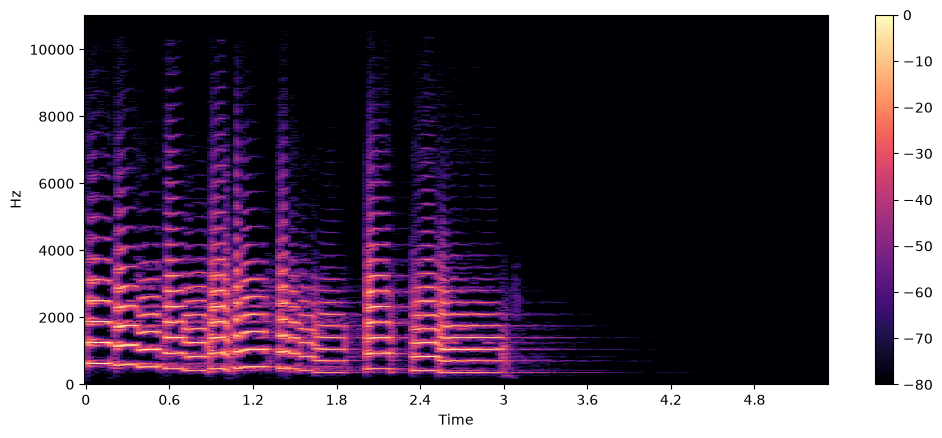

In [25]:
import numpy as np

D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()

**Mel Spectogram**
---
A mel spectrogram is a variation of the spectrogram that is commonly used in speech processing and machine learning tasks. It is similar to a spectrogram in that it shows the frequency content of an audio signal over time, but on a different frequency axis.

In a standard spectrogram, the frequency axis is linear and is measured in hertz (Hz). However, the human auditory system is more sensitive to changes in lower frequencies than higher frequencies, and this sensitivity decreases logarithmically as frequency increases. The mel scale is a perceptual scale that approximates the non-linear frequency response of the human ear.

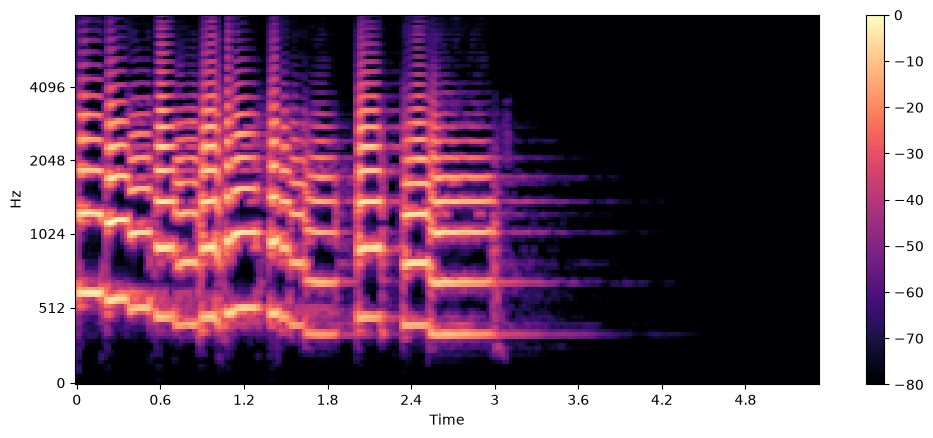

In [27]:
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sampling_rate, fmax=8000)
plt.colorbar()
plt.show()